#Problem 4c

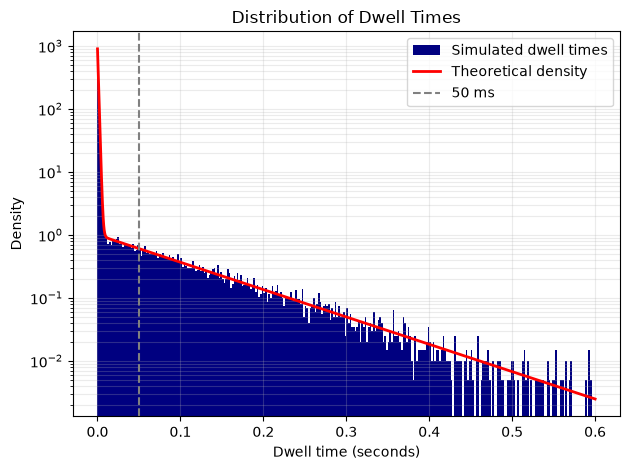

Theoretical mean: 0.01090 seconds
Empirical mean: 0.01093 seconds
Theoretical P(T > 50 ms): 0.06065
Empirical P(T > 50 ms): 0.06154


In [17]:
import numpy as np
from matplotlib import pyplot as plt

#Number of trials
n = 10 ** 5

#List of Dwell times
dwell_times = []
#Function that does the inverse part
def inverse(x, lambda_):
    return (-1 / lambda_) * np.log(1 - x)

#for loop doing inverse transform
for i in range(n):
    b = np.random.binomial(1, 0.9)
    u = np.random.uniform(0, 1)
    if b == 1:
        x = inverse(u, 1000)
    else:
        x = inverse(u, 10)
    dwell_times.append(x)

#Calculate emp dwell prob, other stats
dwell_greater_50 = []
for dwell_time in dwell_times:
    if dwell_time > 0.050:
        dwell_greater_50.append(dwell_time)

emp_P_greater_50 = len(dwell_greater_50) / len(dwell_times)
emp_mean = sum(dwell_times) / len(dwell_times)
theor_mean = 0.9 * (1 / 1000) + 0.1 * (1 / 10)
theor_P_greater_50 = 0.9 * (np.exp(-1000 * 0.050)) + 0.1 * (np.exp(-10 * 0.050))

#Plot the distribution of dwell time
t_grid = np.linspace(0, 0.6, 2000)

f_grid = (
    0.9 * 1000 * np.exp(-1000 * t_grid)
    + 0.1 * 10 * np.exp(-10 * t_grid)
)

plt.hist(
    dwell_times,
    bins = np.linspace(0, 0.6, 301),
    density = True,
    color = "navy",
    label = "Simulated dwell times"
    )

plt.plot(
    t_grid,
    f_grid,
    color = "red",
    linewidth = 2,
    label = "Theoretical density"
)

plt.axvline(0.05, color = "gray", linestyle = "--", label = "50 ms")

plt.yscale("log")
plt.xlabel("Dwell time (seconds)")
plt.ylabel("Density")
plt.title("Distribution of Dwell Times")
plt.grid(alpha = 0.25, which = "both")
plt.legend()
plt.tight_layout()
plt.show()

#Print the stats out
print(f"Theoretical mean:{theor_mean: .5f} seconds")
print(f"Empirical mean:{emp_mean: .5f} seconds")
print(f"Theoretical P(T > 50 ms):{theor_P_greater_50: .5f}")
print(f"Empirical P(T > 50 ms):{emp_P_greater_50: .5f}")
